# Notebook 02 — Emotion Classification

**Goal**: Run `cardiffnlp/twitter-roberta-base-emotion` on the cleaned tweets
to obtain per-tweet emotion probabilities (anger, fear, joy, sadness, surprise, disgust),
plus derived arousal and valence scores.

Sections:
1. Setup
2. Load cleaned tweets
3. Load model and run inference
4. Inspect predictions
5. Emotion distribution analysis
6. Export annotated dataset

In [36]:
# ── 1. Setup ──────────────────────────────────────────────────────────────
import sys, os

# Robust path: works whether notebook is run from repo root, notebooks/, or Colab
_nb_dir = os.path.dirname(os.path.abspath(globals().get("__file__", os.getcwd())))
_repo_root = _nb_dir if os.path.isdir(os.path.join(_nb_dir, "src")) else os.path.dirname(_nb_dir)
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import src.emotion_classifier as _ec
importlib.reload(_ec)
from src.emotion_classifier import EmotionClassifier
from src.evaluation import EMOTION_COLORS

OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [37]:
# ── 2. Load cleaned tweets ────────────────────────────────────────────────
tweets = pd.read_csv(f"{OUTPUT_DIR}/tweets_cleaned.csv")
print(f"Loaded {len(tweets):,} tweets from {tweets['fixture_id'].nunique()} matches")
tweets[["fixture_id","window_5min","text_clean"]].head(5)

Loaded 14,474 tweets from 42 matches


,fixture_id,window_5min,text_clean
0,11867556,105,Record attendance and crowd noise at Bournemou...
1,11867556,110,Bournemouth take the lead as Calum Wilson acro...
2,11867556,110,You’d be forgiven for thinking that this was a...
3,11867556,110,Shit that’s a handball Bournemouth EPL Spurs
4,11867556,110,That was definitely a hand-ball but is that th...


In [38]:
# ── 3. Load model and run inference ──────────────────────────────────────
# NOTE: First run will download ~500 MB of model weights.
# On Colab: GPU recommended (Runtime → Change runtime type → T4 GPU)

clf = EmotionClassifier()  # auto-detects GPU

# Run on the full dataset (batched)
tweets = clf.predict_df(tweets, text_col="text_clean", batch_size=64)
emotion_cols = [c for c in tweets.columns if c in list(clf.labels) + ['arousal', 'valence', 'dominant_emotion']]
print(f"Emotion columns added: {emotion_cols}")
tweets.head(3)

[EmotionClassifier] Loading SamLowe/roberta-base-go_emotions on cpu ...


tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

[EmotionClassifier] 28 labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
Emotion columns added: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral', 'dominant_emotion', 'arousal', 'valence']


,fixture_id,match,kickoff_utc,created_at,relative_minute_from_kickoff,window_5min,text,text_clean,polarity,home_team,...,pride,realization,relief,remorse,sadness,surprise,neutral,dominant_emotion,arousal,valence
0,11867556,AFC Bournemouth vs Tottenham Hotspur,2020-07-09 17:00:00+00:00,2020-07-09 18:49:49+00:00,109.816667,105,Record attendance and crowd noise at Bournemou...,Record attendance and crowd noise at Bournemou...,0.0000,AFC Bournemouth,...,0.000876,0.006325,0.000654,0.000400,0.002418,0.003317,0.923562,neutral,0.323790,0.028715
1,11867556,AFC Bournemouth vs Tottenham Hotspur,2020-07-09 17:00:00+00:00,2020-07-09 18:50:04+00:00,110.066667,110,Bournemouth take the lead as Calum Wilson acro...,Bournemouth take the lead as Calum Wilson acro...,0.0000,AFC Bournemouth,...,0.000887,0.037845,0.001440,0.000438,0.002679,0.000804,0.905774,neutral,0.324673,0.060364
2,11867556,AFC Bournemouth vs Tottenham Hotspur,2020-07-09 17:00:00+00:00,2020-07-09 18:50:23+00:00,110.383333,110,@CFCDaddy You’d be forgiven for thinking that ...,You’d be forgiven for thinking that this was a...,0.4389,AFC Bournemouth,...,0.000341,0.024589,0.000812,0.001183,0.011391,0.000534,0.906773,neutral,0.322858,-0.017572


In [39]:
# ── 4. Inspect predictions ────────────────────────────────────────────────
emotion_cols = [c for c in ["anger","fear","joy","sadness","surprise","disgust"] if c in tweets.columns]

print("Mean emotion probabilities across all tweets:")
print(tweets[emotion_cols].mean().round(4).to_string())
print(f"\nDominant emotion distribution:")
print(tweets["dominant_emotion"].value_counts().to_string())

Mean emotion probabilities across all tweets:
anger       0.0271
fear        0.0057
joy         0.0188
sadness     0.0157
surprise    0.0137
disgust     0.0120

Dominant emotion distribution:
dominant_emotion
neutral           8700
admiration        1362
curiosity          515
disappointment     494
annoyance          440
anger              350
approval           241
optimism           238
excitement         237
amusement          212
love               208
disapproval        206
joy                175
surprise           166
confusion          155
desire             133
sadness            125
disgust            125
gratitude          101
embarrassment       76
fear                67
caring              54
remorse             42
nervousness         27
realization         22
pride                2
relief               1


In [40]:
# Sample high-confidence predictions
for emo in emotion_cols:
    top = tweets.nlargest(1, emo)
    print(f"\nTop {emo} tweet (p={top[emo].values[0]:.3f}):")
    print(f'  "{top["text_clean"].values[0]}"')


Top anger tweet (p=0.838):
  "Fuck off, VAR ruin football 😡 cpfc CRYMUN"

Top fear tweet (p=0.877):
  "What an absolutely terrible decision CFC Chelsea"

Top joy tweet (p=0.912):
  "Fuck me I’m happy 😃 Taken awhile but we look good. Few beers tonight! EFC"

Top sadness tweet (p=0.916):
  "I miss VAR... cpfc"

Top surprise tweet (p=0.869):
  "Kinda surprised we made no changes at HT. We’re far too deep and that’s giving us too much work to do to get up the other end LCFC"

Top disgust tweet (p=0.860):
  "Seriously giving up with football. The blatant cheating is disgusting, game’s gone. cpfc"


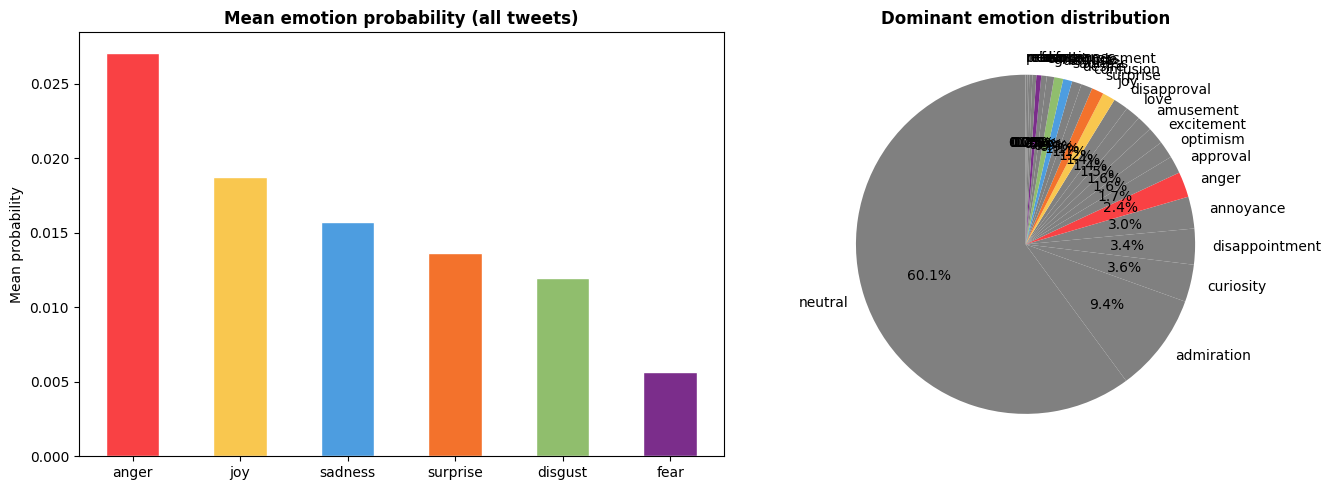

In [41]:
# ── 5. Emotion distribution analysis ─────────────────────────────────────
# (a) Overall distribution
mean_probs = tweets[emotion_cols].mean().sort_values(ascending=False)
colors = [EMOTION_COLORS.get(e, "grey") for e in mean_probs.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
mean_probs.plot(kind="bar", ax=axes[0], color=colors, edgecolor="white")
axes[0].set_title("Mean emotion probability (all tweets)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Mean probability")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

# Pie chart of dominant emotion
dom_counts = tweets["dominant_emotion"].value_counts()
pie_colors = [EMOTION_COLORS.get(e, "grey") for e in dom_counts.index]
axes[1].pie(dom_counts.values, labels=dom_counts.index, colors=pie_colors,
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Dominant emotion distribution", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/emotion_distribution.png", dpi=150)
plt.show()

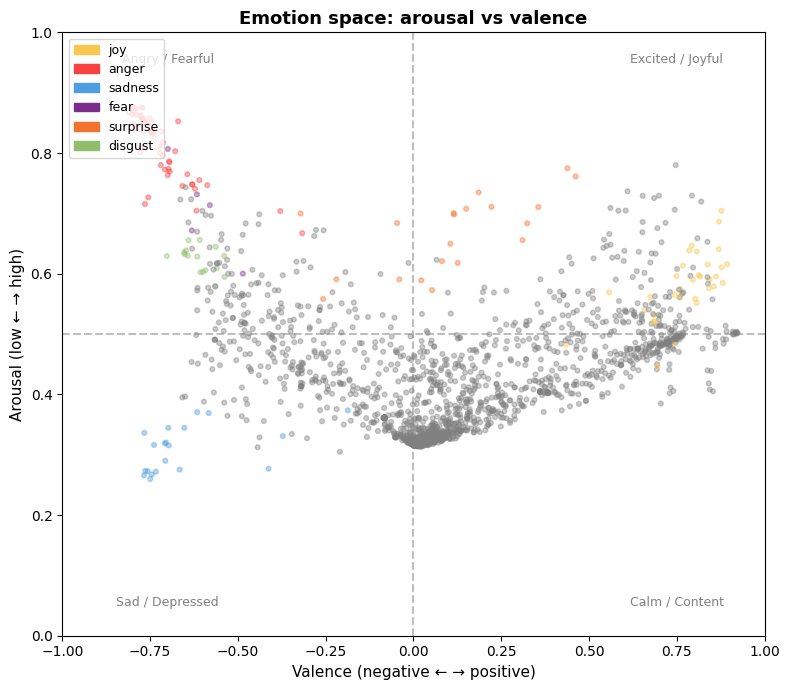

In [42]:
# (b) Arousal vs valence scatter
sample = tweets.sample(min(2000, len(tweets)), random_state=42)
colors_scatter = [EMOTION_COLORS.get(e, "grey") for e in sample["dominant_emotion"]]

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(sample["valence"], sample["arousal"], c=colors_scatter, alpha=0.4, s=12)

# Add legend manually
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=v, label=k) for k, v in EMOTION_COLORS.items() if k in tweets["dominant_emotion"].unique()]
ax.legend(handles=handles, loc="upper left", fontsize=9)

ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5)
ax.axvline(0,   color="grey", linestyle="--", alpha=0.5)
ax.set_xlabel("Valence (negative ← → positive)", fontsize=11)
ax.set_ylabel("Arousal (low ← → high)", fontsize=11)
ax.set_title("Emotion space: arousal vs valence", fontsize=13, fontweight="bold")
ax.set_xlim(-1, 1)
ax.set_ylim(0, 1)

# Quadrant labels
ax.text(0.75, 0.95, "Excited / Joyful",  ha="center", fontsize=9, color="grey")
ax.text(-0.7, 0.95, "Angry / Fearful",   ha="center", fontsize=9, color="grey")
ax.text(0.75, 0.05, "Calm / Content",    ha="center", fontsize=9, color="grey")
ax.text(-0.7, 0.05, "Sad / Depressed",   ha="center", fontsize=9, color="grey")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/arousal_valence_scatter.png", dpi=150)
plt.show()

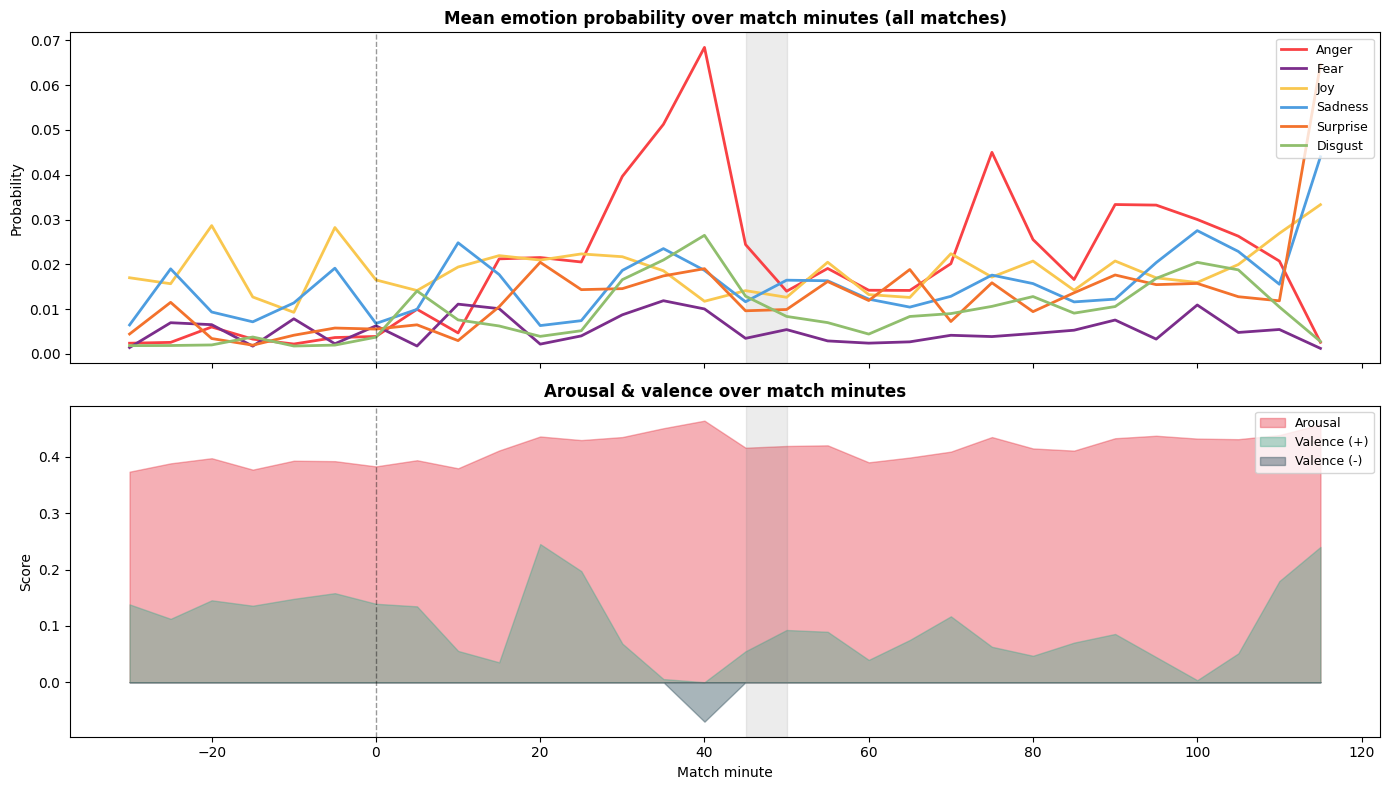

In [43]:
# (c) Emotion over match minutes (all matches pooled)
emotion_by_min = tweets.groupby("window_5min")[emotion_cols + ["arousal","valence"]].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for emo in emotion_cols:
    axes[0].plot(emotion_by_min.index, emotion_by_min[emo],
                 label=emo.capitalize(), color=EMOTION_COLORS.get(emo), linewidth=2)
axes[0].set_title("Mean emotion probability over match minutes (all matches)",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Probability")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.4)
axes[0].axvspan(45, 50, alpha=0.15, color="grey")

axes[1].fill_between(emotion_by_min.index, emotion_by_min["arousal"], alpha=0.4, color="#e63946", label="Arousal")
axes[1].fill_between(emotion_by_min.index, emotion_by_min["valence"].clip(0), alpha=0.4, color="#43aa8b", label="Valence (+)")
axes[1].fill_between(emotion_by_min.index, emotion_by_min["valence"].clip(upper=0), alpha=0.4, color="#264653", label="Valence (-)")
axes[1].set_title("Arousal & valence over match minutes", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Match minute")
axes[1].set_ylabel("Score")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.4)
axes[1].axvspan(45, 50, alpha=0.15, color="grey")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/emotion_over_match_minutes.png", dpi=150)
plt.show()

In [44]:
# ── 6. Export ─────────────────────────────────────────────────────────────
tweets.to_csv(f"{OUTPUT_DIR}/tweets_with_emotions.csv", index=False)
print(f"Exported {len(tweets):,} annotated tweets → {OUTPUT_DIR}/tweets_with_emotions.csv")

Exported 14,474 annotated tweets → ../outputs/tweets_with_emotions.csv
